In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from scipy.interpolate import interp1d

# --- Configuration ---
# Metric to plot
TAG = 'eval/reward' 

def load_tb_data(logdir, tag):
    """
    Loads scalar data from ALL tfevents files in the directory.
    Useful if the logger splits data across multiple files or creates empty init files.
    """
    # Find all event files
    files = glob.glob(os.path.join(logdir, 'events.out.tfevents.*'))
    
    if not files:
        print(f"Warning: No event file found in {logdir}")
        return None, None
    
    # Sort files by modification time (or name) to ensure correct order
    files.sort(key=os.path.getmtime)

    all_steps = []
    all_values = []
    found_data = False

    print(f"\nScanning directory: {os.path.basename(logdir)}")
    
    for event_file in files:
        # Debug: Check file size
        file_size = os.path.getsize(event_file)
        if file_size == 0:
            print(f"  Skipping empty file (0 bytes): {os.path.basename(event_file)}")
            continue
            
        try:
            # Load accumulator for this specific file
            ea = EventAccumulator(event_file, size_guidance={'scalars': 0})
            ea.Reload()
            
            # Check if tag exists in this file
            if tag in ea.Tags()['scalars']:
                events = ea.Scalars(tag)
                steps = [e.step for e in events]
                values = [e.value for e in events]
                
                all_steps.extend(steps)
                all_values.extend(values)
                found_data = True
                print(f"  Found {len(steps)} data points in {os.path.basename(event_file)}")
            else:
                print(f"  Tag '{tag}' not found in {os.path.basename(event_file)}")
                # Optional: Print available tags to debug
                # print(f"    Available tags: {ea.Tags()['scalars']}")
                
        except Exception as e:
            print(f"  Error reading {os.path.basename(event_file)}: {e}")

    if not found_data:
        print(f"Warning: Tag '{tag}' not found in any file in {logdir}")
        return None, None

    # Convert to numpy arrays and sort by step (just in case files were out of order)
    all_steps = np.array(all_steps)
    all_values = np.array(all_values)
    
    # Sort by step index
    sort_idx = np.argsort(all_steps)
    return all_steps[sort_idx], all_values[sort_idx]

def process_group(paths, tag):
    """Loads and interpolates data for a group of paths."""
    all_steps = []
    all_values = []
    
    # Load raw data
    raw_data = []
    for path in paths:
        steps, values = load_tb_data(path, tag)
        if steps is not None:
            raw_data.append((steps, values))
            
    if not raw_data:
        return None, None, None

    # Determine common step axis (using the range of the first run as reference, or global min/max)
    # Here we find the max step common to all or just use a linspace
    min_step = min(d[0][0] for d in raw_data)
    max_step = max(d[0][-1] for d in raw_data)
    
    # Create a common X axis for interpolation
    common_steps = np.linspace(min_step, max_step, num=500)
    
    interpolated_values = []
    for steps, values in raw_data:
        # Interpolate to common_steps
        # fill_value="extrapolate" can be dangerous, better to rely on data range
        f = interp1d(steps, values, kind='linear', fill_value=np.nan, bounds_error=False)
        interpolated_values.append(f(common_steps))
    
    # Stack and compute stats
    data_matrix = np.array(interpolated_values)
    
    # Use nanmean/nanstd to handle cases where runs have different lengths
    mean_vals = np.nanmean(data_matrix, axis=0)
    std_vals = np.nanstd(data_matrix, axis=0)
    
    return common_steps, mean_vals, std_vals


Loading data for tag: eval/reward...


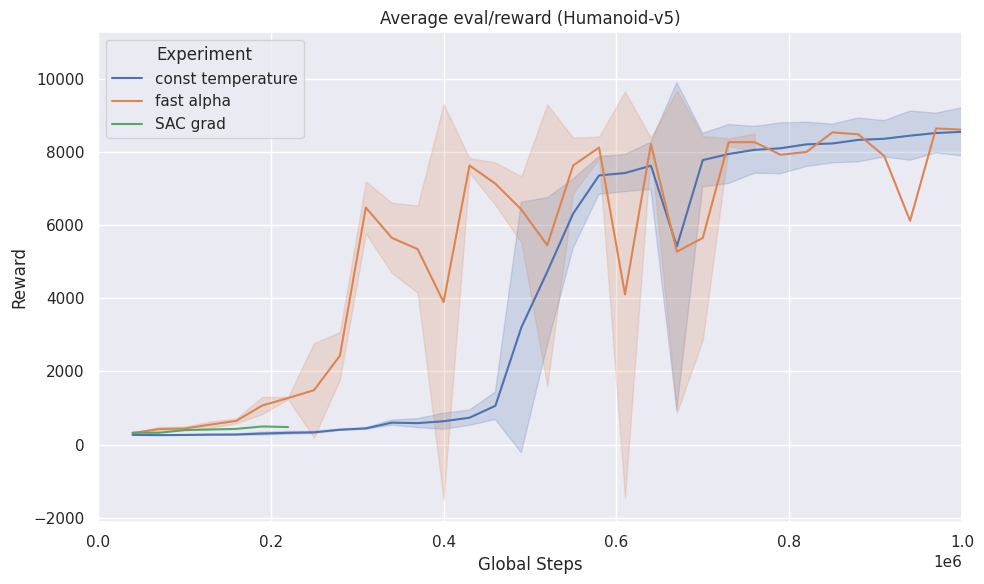

In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def get_event_data(logdir, tag="eval/reward"):
    """
    Finds the tfevents file in the logdir and extracts steps/values for the tag.
    """
    # Find the event file (usually starts with events.out.tfevents...)
    event_files = glob.glob(os.path.join(logdir, "events.out.tfevents*"))
    if not event_files:
        print(f"Warning: No event file found in {logdir}")
        return None

    # Use the first event file found
    event_file = event_files[0]
    
    # Load the event accumulator
    # size_guidance allows loading all data without downsampling
    ea = EventAccumulator(event_file, size_guidance={'scalars': 0})
    ea.Reload()

    if tag not in ea.Tags()['scalars']:
        print(f"Warning: Tag '{tag}' not found in {logdir}")
        return None

    # Extract scalar data
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]

    return pd.DataFrame({"step": steps, "value": values})

# --- Configuration ---
target_tag = "eval/reward"

# Define your groups here
experiments = {
    "const temperature": [
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_2",
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_1",
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_3"
    ],
    "fast alpha": [
        "ASAC_anneal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_8",
        "ASAC_anneal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_9"
    ],
    "SAC grad": [
        "ASAC_nstep1_1.0_0.1_gradentauto_0.2_rho0=0.0_maxgrad=None/ASAC_nstep1_1.0_0.1_gradentauto_0.2_rho0=0.0_maxgrad=None_1"
    ]
}

# --- Data Loading ---
all_data = []

print(f"Loading data for tag: {target_tag}...")

for label, paths in experiments.items():
    for path in paths:
        df = get_event_data(path, tag=target_tag)
        if df is not None:
            df["condition"] = label
            all_data.append(df)

if not all_data:
    print("No data found. Check your paths.")
    quit()

# Concatenate all dataframes
full_df = pd.concat(all_data, ignore_index=True)

# --- Plotting ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="darkgrid")

# Seaborn lineplot aggregates repeated x-values (steps)
# errorbar='sd' draws the standard deviation. Use 'ci' for confidence interval.
sns.lineplot(
    data=full_df,
    x="step",
    y="value",
    hue="condition",
    errorbar='sd' 
)

plt.title(f"Average {target_tag} (Humanoid-v5)")
plt.xlabel("Global Steps")
plt.xlim(0, 1000000)
plt.ylabel("Reward")
plt.legend(title="Experiment")

plt.tight_layout()
plt.show()

In [5]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def get_data_for_tags(logdir, tags):
    """
    Finds the tfevents file in the logdir and extracts steps/values for multiple tags.
    Returns a DataFrame with columns: step, value, tag
    """
    # Find the event file (usually starts with events.out.tfevents...)
    event_files = glob.glob(os.path.join(logdir, "events.out.tfevents*"))
    if not event_files:
        print(f"Warning: No event file found in {logdir}")
        return None

    event_file = event_files[0]
    
    # Load the event accumulator
    try:
        ea = EventAccumulator(event_file, size_guidance={'scalars': 0})
        ea.Reload()
    except Exception as e:
        print(f"Error reading {logdir}: {e}")
        return None

    available_tags = ea.Tags()['scalars']
    
    dfs = []
    for tag in tags:
        if tag in available_tags:
            events = ea.Scalars(tag)
            steps = [e.step for e in events]
            values = [e.value for e in events]
            
            # Create a dataframe for this specific tag
            tag_df = pd.DataFrame({"step": steps, "value": values})
            tag_df["tag"] = tag
            dfs.append(tag_df)
        else:
            # Optional: Warning if a specific tag is missing
            # print(f"Warning: Tag '{tag}' not found in {logdir}")
            pass

    if not dfs:
        return None

    return pd.concat(dfs, ignore_index=True)

# --- Configuration ---
# We want to plot these two tags
plot_tags = ["eval/reward", "train/ent_coef"]

experiments = {
    r"$\alpha=0.2$": [
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_2",
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_1",
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_3"
        "ASAC_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_2",
        "ASAC_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_1",
    ],
    r"$\alpha=0.01$": [
         "ASAC_nstep1_1.0_0.1_gradent0.01_rho0=0.0_maxgrad=None/ASAC_nstep1_1.0_0.1_gradent0.01_rho0=0.0_maxgrad=None_1",
         "ASAC_nstep1_1.0_0.1_gradent0.01_rho0=0.0_maxgrad=None/ASAC_nstep1_1.0_0.1_gradent0.01_rho0=0.0_maxgrad=None_2",
         "ASAC_nstep1_1.0_0.1_gradent0.01_rho0=0.0_maxgrad=None/ASAC_nstep1_1.0_0.1_gradent0.01_rho0=0.0_maxgrad=None_3",
         "0.1_gradent0.01_rho0=0.0_maxgrad=None_4",
         "0.1_gradent0.01_rho0=0.0_maxgrad=None_5"
    ],

    "10x": [
        "mporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_20",
        "mporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_21",
        "mporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_23",

    ],
    "MEW (ours)": [
        "mporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_22",
        "mporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_24",
        "mporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_26",
        "mporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_28",
        "mporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_29",
    ],
    "Min. Entropy": [
        "1.0_0.1_gradentauto_0.2_rho0=0.0_maxgrad=None_1",
        "1.0_0.1_gradentauto_0.2_rho0=0.0_maxgrad=None_2",
        "1.0_0.1_gradentauto_0.2_rho0=0.0_maxgrad=None_3",
        "1.0_0.1_gradentauto_0.2_rho0=0.0_maxgrad=None_4",
        "1.0_0.1_gradentauto_0.2_rho0=0.0_maxgrad=None_5"
        
    ]
}

# --- Data Loading ---
all_data = []

print(f"Loading data for tags: {plot_tags}...")

for label, paths in experiments.items():
    for path in paths:
        # We fetch both tags at once to avoid re-reading the file
        df = get_data_for_tags(path, tags=plot_tags)
        if df is not None:
            df["condition"] = label
            all_data.append(df)

# if not all_data:
#     print("No data found. Check your paths.")
#     return

# Concatenate all dataframes
full_df = pd.concat(all_data, ignore_index=True)


Loading data for tags: ['eval/reward', 'train/ent_coef']...


ValueError: No objects to concatenate

ValueError: The palette dictionary is missing keys: {'$\\alpha=0.01$', 'Min. Entropy', 'Proposed Method', '$\\alpha=0.2$'}

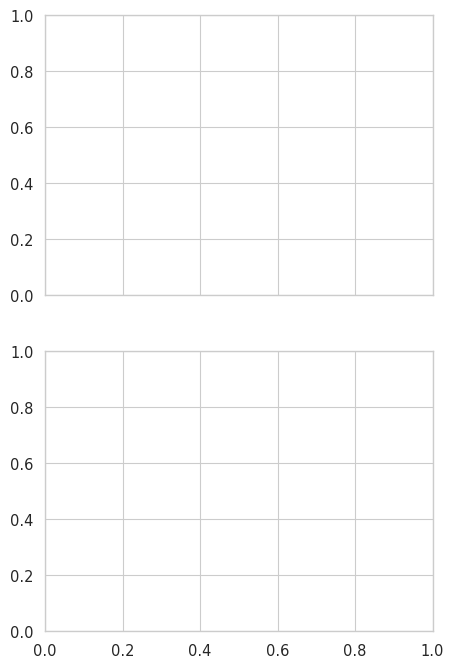

In [6]:
# Cleaned plotting for paper
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = {"Constant Alpha=0.01": "#1f77b4", "Constant Alpha=0.2": "#ff0e0e", "MEW (ours)": "#45bd16", "SAC Auto. Temperature": "#000000", "10x": "#ffa500", "0.1x": "#800080"}

fig, axes = plt.subplots(2, 1, figsize=(5, 8), sharex=True)

# 1. eval/reward
sns.lineplot(
    data=full_df[full_df["tag"] == "eval/reward"],
    x="step",
    y="value",
    hue="condition",
    errorbar="se",
    ax=axes[0],
    palette=palette,
    linewidth=2,
    legend=False
)
# axes[0].set_title("Humanoid-v5: eval/reward")
axes[0].set_xlabel("Env. Steps")
axes[0].set_ylabel("Eval. Return")
axes[0].set_xlim(0, 1_000_000)
axes[0].set_ylim(0, 10_000)
# axes[0].legend(title="", fontsize=10)

# 2. train/ent_coef
sns.lineplot(
    data=full_df[full_df["tag"] == "train/ent_coef"],
    x="step",
    y="value",
    hue="condition",
    errorbar="se",
    ax=axes[1],
    palette=palette,
    linewidth=2,
    # legend=False
)
# axes[1].set_title("Temperature (train/ent_coef)")
axes[1].set_xlabel("Env. Steps")
axes[1].set_ylabel("Temperature")
axes[1].set_xlim(10_000, 1_000_000)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].legend(title="", fontsize=14)


sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_382281/254123237.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=full_df[full_df["tag"] == "train/ent_coef"][~full_df["condition"].isin(["Constant Alpha=0.01", "Constant Alpha=0.2"])],
/tmp/ipykernel_382281/254123237.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


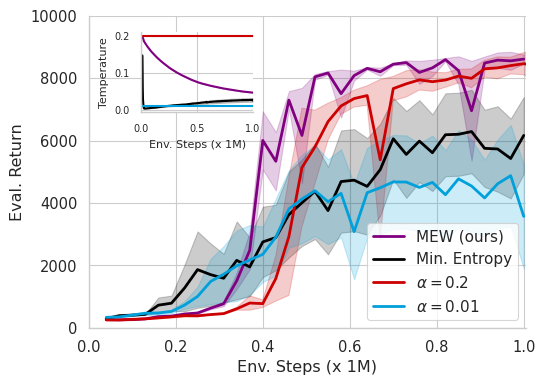

In [7]:
# Cleaned plotting for paper
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = {r"$\alpha=0.01$": "#00a0db", r"$\alpha=0.2$": "#cc0000", "Proposed Method": "#45bd16", "Min. Entropy": "#000000", "10x": "#ffa500", "MEW (ours)": "#800080"}
fig, ax_main = plt.subplots(1, 1, figsize=(5.6, 4))
# rm the 10x and proposed method for clarity
full_df = full_df[~full_df["condition"].isin(["10x", "Proposed Method"])]
# Main plot: eval/reward
# sort as MEW (ours), Min. Entropy, alpha=0.2, alpha=0.01:
full_df["condition"] = pd.Categorical(full_df["condition"], categories=["MEW (ours)", "Min. Entropy", r"$\alpha=0.2$", r"$\alpha=0.01$"], ordered=True)
sns.lineplot(
    data=full_df[full_df["tag"] == "eval/reward"],
    x="step",
    y="value",
    hue="condition",
    errorbar="se",
    ax=ax_main,
    palette=palette,
    linewidth=2,
    legend=True
)
ax_main.set_xlabel("Env. Steps (x 1M)")
ax_main.set_ylabel("Eval. Return")
ax_main.set_xlim(0, 1_005_001)
ax_main.set_ylim(0, 10_000)
ax_main.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{round(x/1e6, 2)}'))
ax_main.legend(title="", fontsize=11, loc='lower right')

# Inset plot: train/ent_coef
ax_inset = fig.add_axes([0.265, 0.7, 0.2, 0.2])  # [left, bottom, width, height]
sns.lineplot(
    # exclude the constant temperature runs for clarity:
    data=full_df[full_df["tag"] == "train/ent_coef"][~full_df["condition"].isin(["Constant Alpha=0.01", "Constant Alpha=0.2"])],
    x="step",
    y="value",
    hue="condition",
    errorbar="se",
    ax=ax_inset,
    palette=palette,
    linewidth=1.5,
    legend=False
)
# ax_inset.set_xlabel("Env. Steps", fontsize=8)
ax_inset.set_ylabel("Temperature", fontsize=8)
ax_inset.set_xlim(0, 1_005_001)
ax_inset.set_xlabel("Env. Steps (x 1M)", fontsize=8)
ax_inset.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{round(x/1e6, 2)}'))
# ax_inset.set_xscale("log")
# ax_inset.set_yscale("log")
# remove x labels:
# ax_inset.set_xticklabels([])
# ax_inset.set_xlabel("")

ax_inset.tick_params(labelsize=7)
# ax_inset.yaxis.tick_right()
# ax_inset.yaxis.set_label_position("right")


sns.despine()
plt.tight_layout()
plt.show()

In [15]:
# --- Update your loading loop section ---
for label, paths in experiments.items():
    for path in paths:
        df = get_data_for_tags(path, tags=plot_tags)
        if df is not None:
            df["condition"] = label
            df["path"] = path  # <--- ADD THIS LINE
            all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

# --- Updated rliable processing ---
eval_df = full_df[full_df["tag"] == "eval/reward"]

# Get the final scores (mean of the last 5% of the run)
last_steps = eval_df.groupby(["condition", "path"])["step"].transform(max)
final_scores_df = eval_df[eval_df["step"] >= (last_steps * 0.95)]

rliable_data = {}
algorithms = ["MEW (ours)", "Min. Entropy", r"$\alpha=0.2$", r"$\alpha=0.01$"]

for condition in algorithms:
    if condition in final_scores_df["condition"].unique():
        cond_data = final_scores_df[final_scores_df["condition"] == condition]
        # Group by path to get one score per seed
        seeds = cond_data.groupby("path")["value"].mean().values
        # rliable expects (runs, games). We have 1 game (Humanoid).
        rliable_data[condition] = seeds.reshape(-1, 1)

/tmp/ipykernel_889074/469154607.py:16: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  last_steps = eval_df.groupby(["condition", "path"])["step"].transform(max)


In [ ]:
# Now compare the results across different "thermodynamic speeds":

experiments = {
    "1e-5": [
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_16",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_17",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_18",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_19",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_15"
    ],
    "1e-4": [
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_20",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_21",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_23",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_25",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_27",
    ],
    "1e-6": [
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_22",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_24",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_26",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_28",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_29",
    ],
    "1e-7": [
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_30",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_31",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_32",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_33",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_34",
    ],
    # Cosntant temp = 0.2
    "0.0": [
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_2",
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_1",
        "ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_anneal_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_3",
        "ASAC_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_2",
        "ASAC_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None/ASAC_nstep1_1.0_0.1_ent0.2_rho0=0.0_maxgrad=None_1",
    ]
}

In [118]:

# --- Data Loading ---
all_data = []

print(f"Loading data for tags: {plot_tags}...")

for label, paths in experiments.items():
    for path in paths:
        # We fetch both tags at once to avoid re-reading the file
        df = get_data_for_tags(path, tags=plot_tags)
        if df is not None:
            df["condition"] = label
            all_data.append(df)

# if not all_data:
#     print("No data found. Check your paths.")
#     return

# Concatenate all dataframes
speeds_df = pd.concat(all_data, ignore_index=True)


Loading data for tags: ['eval/reward', 'train/ent_coef']...


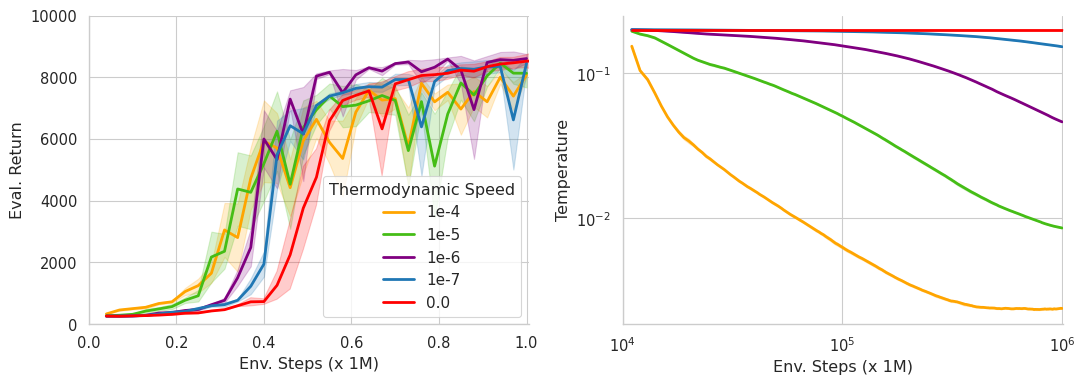

In [132]:

# Cleaned plotting for paper
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = {"1e-5": "#45bd16", "1e-4": "#ffa500", "1e-6": "#800080", "1e-7": "#1f77b4","0.0": "#FF0000"}
# keep only those in the palette:
speeds_df_filtered = speeds_df[speeds_df["condition"].isin(palette.keys())]

fig, (ax_reward, ax_temp) = plt.subplots(1, 2, figsize=(11, 4))
# list in order: [1e-4, 1e-5, 1e-6, 1e-7, 0.0]:
speeds_df_filtered["condition"] = pd.Categorical(speeds_df_filtered["condition"], categories=["1e-4", "1e-5", "1e-6", "1e-7", "0.0"], ordered=True)
# Left plot: eval/reward
sns.lineplot(
    data=speeds_df_filtered[speeds_df_filtered["tag"] == "eval/reward"],
    x="step",
    y="value",
    hue="condition",
    errorbar="se",
    ax=ax_reward,
    palette=palette,
    linewidth=2,
    legend=True
)

ax_reward.set_xlabel("Env. Steps (x 1M)")
ax_reward.set_ylabel("Eval. Return")
ax_reward.set_xlim(0, 1_005_001)
ax_reward.set_ylim(0, 10_000)
ax_reward.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{round(x/1e6, 2)}'))
ax_reward.legend(title="Thermodynamic Speed", fontsize=11, loc='lower right')

# Right plot: train/ent_coef
sns.lineplot(
    data=speeds_df_filtered[speeds_df_filtered["tag"] == "train/ent_coef"],
    x="step",
    y="value",
    hue="condition",
    errorbar="se",
    ax=ax_temp,
    palette=palette,
    linewidth=2,
    legend=False
)

ax_temp.set_xlabel("Env. Steps (x 1M)")
ax_temp.set_ylabel("Temperature")
ax_temp.set_xlim(10_000, 1_005_001)
ax_temp.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{round(x/1e6, 2)}'))
ax_temp.set_yscale("log")
ax_temp.set_xscale("log")

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# Now compare the results across different "thermodynamic speeds":

experiments = {

    r"$500$": [
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500_1",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500_2",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500_3",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500_4",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist500_5",
    ],
    r"$5,000$": [
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_22",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_24",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_26",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_28",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_29",
    ],
    r"$50,000$": [
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist50000/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist50000_4",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist50000/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist50000_3",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist50000/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist50000_2",
        "ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist50000/ASAC_temporal_nstep1_1.0_0.1_entauto_0.2_rho0=0.0_maxgrad=None_hist50000_6",
    ],

}

In [145]:

# --- Data Loading ---
all_data = []

print(f"Loading data for tags: {plot_tags}...")

for label, paths in experiments.items():
    for path in paths:
        # We fetch both tags at once to avoid re-reading the file
        df = get_data_for_tags(path, tags=plot_tags)
        if df is not None:
            df["condition"] = label
            all_data.append(df)

# if not all_data:
#     print("No data found. Check your paths.")
#     return

# Concatenate all dataframes
times_df = pd.concat(all_data, ignore_index=True)


Loading data for tags: ['eval/reward', 'train/ent_coef']...


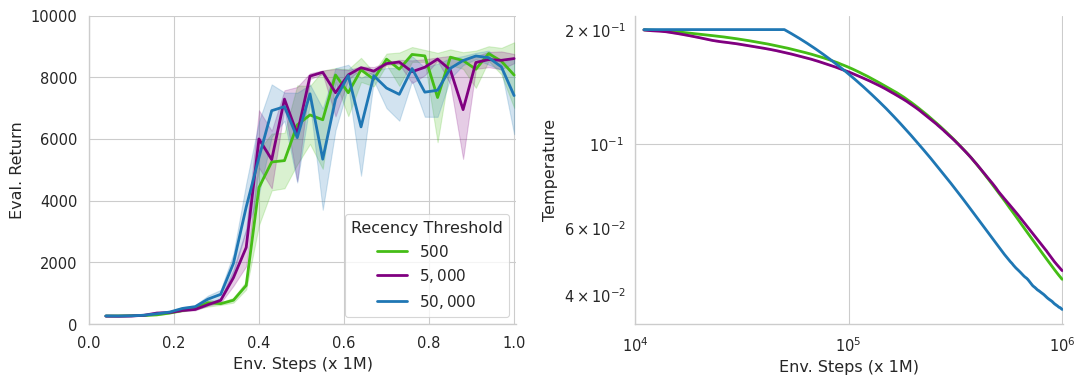

In [149]:

# Cleaned plotting for paper
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = {r"$500$": "#45bd16", r"$5,000$": "#800080", r"$50,000$": "#1f77b4"}
# keep only those in the palette:
times_df_filtered = times_df[times_df["condition"].isin(palette.keys())]

fig, (ax_reward, ax_temp) = plt.subplots(1, 2, figsize=(11, 4))
# list in order: [500, 5k]:
times_df_filtered["condition"] = pd.Categorical(times_df_filtered["condition"], categories=[r"$500$", r"$5,000$", r"$50,000$"], ordered=True)
# Left plot: eval/reward
sns.lineplot(
    data=times_df_filtered[times_df_filtered["tag"] == "eval/reward"],
    x="step",
    y="value",
    hue="condition",
    errorbar="se",
    ax=ax_reward,
    palette=palette,
    linewidth=2,
    legend=True
)

ax_reward.set_xlabel("Env. Steps (x 1M)")
ax_reward.set_ylabel("Eval. Return")
ax_reward.set_xlim(0, 1_005_001)
ax_reward.set_ylim(0, 10_000)
ax_reward.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{round(x/1e6, 2)}'))
ax_reward.legend(title="Recency Threshold", fontsize=11, loc='lower right')

# Right plot: train/ent_coef
sns.lineplot(
    data=times_df_filtered[times_df_filtered["tag"] == "train/ent_coef"],
    x="step",
    y="value",
    hue="condition",
    errorbar="se",
    ax=ax_temp,
    palette=palette,
    linewidth=2,
    legend=False
)

ax_temp.set_xlabel("Env. Steps (x 1M)")
ax_temp.set_ylabel("Temperature")
ax_temp.set_xlim(10_000, 1_005_001)
ax_temp.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{round(x/1e6, 2)}'))
ax_temp.set_yscale("log")
ax_temp.set_xscale("log")

sns.despine()
plt.tight_layout()
plt.show()
